In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch
from scipy.constants import c

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
})

import ltatools as lta
from ltatools.style import axis_label

FIGSIZE_MODES = (7, 9)

# ---------------------------------------------------------------------------
# Filter parameters of "neXt". Every number below is either taken from a page
# of the thesis vault (page named in the comment) or flagged `TODO: unsourced`.
# Nothing without provenance is drawn -- the unsourced values are used for the
# annotations and the summary table only, never to place a curve.
# ---------------------------------------------------------------------------

NU_OP = 268.095e12                 # ~1118.2 nm (268.095 THz)"; c/lambda gives 268.103 THz)
LAMBDA_OP_NM = c / NU_OP * 1e9      # 1118.2 nm

# Gain envelope. The span is DISPUTED across sources (wiki/gain-chip.md,
# "Contradiction: two different gain-envelope spans"): 1116-1122 nm from
# Kiefer 2020 and the 2026 tutorial, 1118-1126 nm from the two Spanke theses,
# and ~1115-1130 nm read off the spectrum plot in the chip's own Vexlum
# factory report (C0186 -- the unit actually installed, and the only primary
# source for THIS chip, which is why it is the default). To switch, change the
# key and nothing else.
GAIN_SPAN_OPTIONS_NM = {
    'factory_C0186': (1115.0, 1130.0),    # raw/datasheets/2023-05-17_C0186_test_report.pdf, via wiki/gain-chip.md
    'kiefer_tutorial': (1116.0, 1122.0),  # wiki/gain-chip.md, wiki/vecsel.md
    'spanke': (1118.0, 1126.0),           # wiki/gain-chip.md, wiki/vecsel.md
}
GAIN_SPAN_KEY = 'factory_C0186'  # change this to switch the gain span used in the figure
GAIN_LO_NM, GAIN_HI_NM = GAIN_SPAN_OPTIONS_NM[GAIN_SPAN_KEY]

# Birefringent filter. No source in the vault gives a number. The tutorial has
# only "one broad transmission lobe, sub-nm wide (~100s of GHz)", repeated on
# wiki/birefringent-filter.md and wiki/vecsel.md as "sub-nm". Those two
# statements together bound it: sub-nm at 1118 nm means < 240 GHz, so the
# placeholder sits at the top of the range that satisfies both.
BRF_FWHM_GHZ = 200.0    # TODO: unsourced
BRF_FSR_THZ = 10.0      # TODO: unsourced -- only constrained by the tutorial's "one broad
                        # lobe", i.e. one lobe inside the gain envelope, so FSR > 3.6 THz.
                        # Deliberately NOT drawn: see brf_transmission().

# Etalon: LightMachinery OP-11596, the part in neXt's own appendix test report
# (wiki/etalon.md, resolution box of 2026-08-06) -- 306 pm at its 1064.15 nm
# design wavelength, i.e. 81 GHz. The 72 GHz and ~73 GHz records on the same
# page belong to VECSEL Nr.4, a physically different laser, and that page says
# in as many words not to cite them for neXt. So no sourced neXt FSR at 1118 nm
# exists and the design-wavelength value is what gets used. Defensible anyway:
# FSR = c/2nL is set by the etalon's optical thickness, not by the wavelength
# probing it, so it is the 306 pm -> 72/73 GHz reconversion at 1120 nm that
# needs justifying, not the 81 GHz.
ETALON_FSR_GHZ = 81.0
ETALON_FINESSE = 1.0    # wiki/etalon.md: "Finesse (as configured in cavity) | ~1.0"

# Cavity: L = 127.5 mm -> FSR = c/2L = 1.18 GHz (wiki/vecsel.md, "The
# mode-selection budget"; the same L is used on wiki/piezo-cavity-tuning.md).
CAVITY_L_M = 0.1275
CAVITY_FSR_GHZ = c / (2 * CAVITY_L_M) / 1e9

# Half-width of each zoom panel and the tick step inside it, both in GHz.
# Panel 1 is set by the gain span instead.
PANEL_HALFSPAN_GHZ = (None, 220.0, 1.5 * ETALON_FSR_GHZ, 5.0)
PANEL_TICKSTEP_GHZ = (None, 100.0, ETALON_FSR_GHZ, 2.0)

GAIN_LO_HZ, GAIN_HI_HZ = c / (GAIN_HI_NM * 1e-9), c / (GAIN_LO_NM * 1e-9)
GAIN_SPAN_HZ = GAIN_HI_HZ - GAIN_LO_HZ

# Nested mode-selection scales of the "neXt" cavity (gain / BRF / etalon / longitudinal mode)

In [2]:
def thz_to_nm(f_thz):
    """nu -> lambda for the secondary axis. matplotlib probes the transform at
    0, so the division warning is silenced rather than printed at every draw."""
    with np.errstate(divide='ignore', invalid='ignore'):
        return c / (np.asarray(f_thz, dtype=float) * 1e12) * 1e9


def nm_to_thz(w_nm):
    with np.errstate(divide='ignore', invalid='ignore'):
        return c / (np.asarray(w_nm, dtype=float) * 1e-9) / 1e12


def width_nm(width_hz, lambda_nm=LAMBDA_OP_NM):
    """A spectral WIDTH in Hz expressed in nm, |dlambda| = lambda^2/c * dnu.
    Only valid as a local conversion -- it is the derivative, not c/nu."""
    return width_hz * (lambda_nm * 1e-9) ** 2 / c * 1e9


def gain_envelope(nu):
    """Gain profile: super-Gaussian whose FWHM is the quoted span.

    SCHEMATIC. No source gives a lineshape -- every span above is quoted as a
    pair of bounds (the widest was read off a plot), not as a fitted FWHM. Only
    the width and the centre carry information here; the shape carries none.
    """
    nu_c = 0.5 * (GAIN_LO_HZ + GAIN_HI_HZ)
    return np.exp(-np.log(2) * (2 * (nu - nu_c) / GAIN_SPAN_HZ) ** 6)


def brf_transmission(nu, central_lobe_only=True):
    """Lyot-filter lobe, T = cos^2(delta) (wiki/birefringent-filter.md), written
    so its FWHM is BRF_FWHM_GHZ.

    Only the CENTRAL lobe is returned by default. A cos^2 of that FWHM repeats
    every 2*FWHM, but the real lobe spacing is BRF_FSR_THZ, which is unsourced
    and far larger -- drawing the repeats would put a number on the page that
    the vault does not have. Off-lobe values come back as NaN so nothing is
    drawn there.
    """
    t = np.cos(np.pi / 2 * (nu - NU_OP) / (BRF_FWHM_GHZ * 1e9)) ** 2
    if central_lobe_only:
        t = np.where(np.abs(nu - NU_OP) <= BRF_FWHM_GHZ * 1e9, t, np.nan)
    return t


def etalon_transmission(nu):
    """Airy transmission, I/I0 = 1/(1 + F sin^2(pi dnu / FSR)).

    Coefficient of finesse F = 4*Fin^2/pi^2. (wiki/etalon.md prints
    F = 4*Fin/pi^2; at Fin = 1.0 the two agree, so nothing here turns on which
    reading is right.) At Fin = 1.0 this is a WEAK Fabry-Perot: F = 0.41 and
    the transmission only swings between 1.00 and 0.71. It never reaches half
    maximum, so the etalon has no passband FWHM at all -- which is why that
    panel is annotated with a contrast ratio instead. Not a plotting
    compromise, it is what a finesse of 1 means.
    """
    F = 4 * ETALON_FINESSE ** 2 / np.pi ** 2
    return 1 / (1 + F * np.sin(np.pi * (nu - NU_OP) / (ETALON_FSR_GHZ * 1e9)) ** 2)


def cavity_comb(nu, width_ghz=0.02):
    """Longitudinal-mode comb: Lorentzian teeth on the c/2L grid, phased so that
    a mode sits exactly on the operating point (which is what the PZT enforces).
    The tooth width is cosmetic -- the cavity linewidth is not what this figure
    is about."""
    n = np.round((nu - NU_OP) / (CAVITY_FSR_GHZ * 1e9))
    return 1 / (1 + ((nu - NU_OP - n * CAVITY_FSR_GHZ * 1e9) / (width_ghz * 1e9)) ** 2)

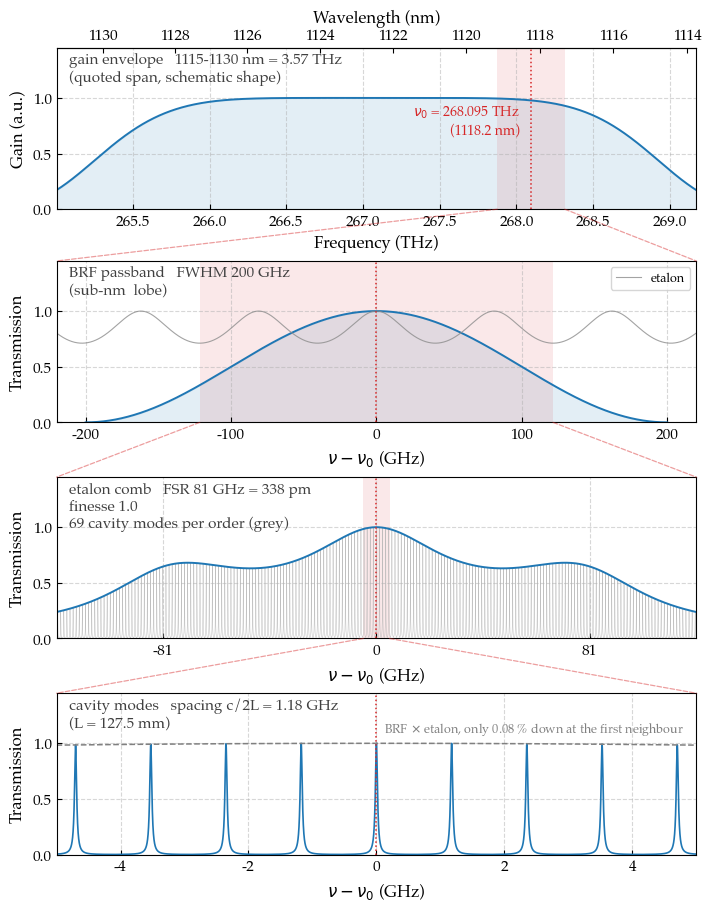

In [5]:
fig, axes = plt.subplots(4, 1, figsize=FIGSIZE_MODES, constrained_layout=True)
ax_gain, ax_brf, ax_et, ax_cav = axes

col = lta.COLORS['frequency']
ANN = dict(xycoords='axes fraction', ha='left', va='top', fontsize=11, color='0.25')

# --- panel 1: gain envelope ------------------------------------------------
nu1 = np.linspace(GAIN_LO_HZ - 0.3e12, GAIN_HI_HZ + 0.3e12, 4000)
ax_gain.plot(nu1 / 1e12, gain_envelope(nu1), color=col, lw=1.4)
ax_gain.fill_between(nu1 / 1e12, gain_envelope(nu1), color=col, alpha=0.12)
ax_gain.set_xlim(nu1[0] / 1e12, nu1[-1] / 1e12)
ax_gain.set_xlabel(axis_label('frequency', 'THz'))
ax_gain.set_ylabel('Gain (a.u.)')
ax_gain.annotate(f'gain envelope   {GAIN_LO_NM:.0f}-{GAIN_HI_NM:.0f} nm '
                 f'= {GAIN_SPAN_HZ / 1e12:.2f} THz\n(quoted span, schematic shape)',
                 xy=(0.02, 0.97), **ANN)

# Second axis in nm: the envelope is quoted in nm in every source, and the
# mapping is 1/x, so the two axes necessarily run in opposite directions.
sec = ax_gain.secondary_xaxis('top', functions=(thz_to_nm, nm_to_thz))
sec.set_xlabel('Wavelength (nm)')

# --- panel 2: BRF lobe -----------------------------------------------------
h2 = PANEL_HALFSPAN_GHZ[1] * 1e9
nu2 = np.linspace(NU_OP - h2, NU_OP + h2, 4000)
ax_brf.plot(nu2, brf_transmission(nu2), color=col, lw=1.4)
ax_brf.fill_between(nu2, brf_transmission(nu2), color=col, alpha=0.12)
# The etalon orders the lobe has to choose between, for scale.
ax_brf.plot(nu2, etalon_transmission(nu2), color='0.55', lw=0.8, ls='-', alpha=0.8,
            label='etalon')
ax_brf.set_ylabel('Transmission')
ax_brf.annotate(f'BRF passband   FWHM {BRF_FWHM_GHZ:.0f} GHz '
                #f'= {width_nm(BRF_FWHM_GHZ * 1e9):.2f} nm\n'
                f'\n(sub-nm  lobe)',
                xy=(0.02, 0.97), **ANN)
ax_brf.legend(loc='upper right', fontsize=9)

# --- panel 3: etalon comb --------------------------------------------------
h3 = PANEL_HALFSPAN_GHZ[2] * 1e9
nu3 = np.linspace(NU_OP - h3, NU_OP + h3, 40000)
# Cavity comb underneath, to show how many modes one etalon order still passes.
ax_et.plot(nu3, cavity_comb(nu3, width_ghz=0.06) * etalon_transmission(nu3) * brf_transmission(nu3),
           color='0.7', lw=0.35, alpha=0.85)
ax_et.plot(nu3, etalon_transmission(nu3)  * brf_transmission(nu3), color=col, lw=1.4)
ax_et.set_ylabel('Transmission')
ax_et.annotate(f'etalon comb   FSR {ETALON_FSR_GHZ:.0f} GHz '
               f'= {width_nm(ETALON_FSR_GHZ * 1e9) * 1e3:.0f} pm\n'
               f'finesse {ETALON_FINESSE:.1f}'
               #f'{1 + 4 * ETALON_FINESSE ** 2 / np.pi ** 2:.2f}:1; '
               f'\n{ETALON_FSR_GHZ / CAVITY_FSR_GHZ:.0f} cavity modes per order (grey)',
               xy=(0.02, 0.97), **ANN)

# --- panel 4: cavity mode comb ---------------------------------------------
h4 = PANEL_HALFSPAN_GHZ[3] * 1e9
nu4 = np.linspace(NU_OP - h4, NU_OP + h4, 40000)
sel = brf_transmission(nu4, central_lobe_only=False) * etalon_transmission(nu4)
ax_cav.plot(nu4, cavity_comb(nu4) * sel, color=col, lw=1.2)
# The combined filter over this window. It is very nearly flat, and that is the
# result: the etalon does not isolate a mode, it hands a thinned comb to the
# gain competition. The loss advantage of the surviving mode is a number to be
# read off the label, not something the eye can see in the curve.
neighbour = 100 * (1 - etalon_transmission(NU_OP + CAVITY_FSR_GHZ * 1e9))
ax_cav.plot(nu4, sel, ls='--', lw=1.1, color='0.5')
ax_cav.set_ylabel('Transmission')
ax_cav.annotate(f'cavity modes   spacing c/2L = {CAVITY_FSR_GHZ:.2f} GHz '
                #f'= {width_nm(CAVITY_FSR_GHZ * 1e9) * 1e3:.1f} pm'
                f'\n(L = {CAVITY_L_M * 1e3:.1f} mm)',
                xy=(0.02, 0.97), **ANN)
# Label the combined filter on the curve itself: a legend box here would sit on
# top of the very modes the panel exists to show.
ax_cav.annotate(f'BRF $\\times$ etalon, only {neighbour:.2f} % down at the first neighbour',
                xy=(0.98, sel.max()), xycoords=('axes fraction', 'data'),
                xytext=(0, 4), textcoords='offset points',
                ha='right', va='bottom', fontsize=9, color='0.5')

# --- common formatting -----------------------------------------------------
for ax, half, step in zip(axes[1:], PANEL_HALFSPAN_GHZ[1:], PANEL_TICKSTEP_GHZ[1:]):
    ax.set_xlim(NU_OP - half * 1e9, NU_OP + half * 1e9)
    ticks = np.arange(-np.floor(half / step) * step, half + step / 2, step)
    ticks = ticks[np.abs(ticks) <= half]
    ax.set_xticks(NU_OP + ticks * 1e9)
    ax.set_xticklabels([f'{t:g}' for t in ticks])
    ax.set_xlabel(r'$\nu - \nu_0$ (GHz)')

for ax in axes:
    ax.set_ylim(0, 1.45)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.tick_params(axis='both', direction='in')
    ax.axvline(NU_OP / 1e12 if ax is ax_gain else NU_OP, color='tab:red', lw=1.1, ls=':')

ax_gain.annotate(rf'$\nu_0$ = {NU_OP / 1e12:.3f} THz'
                 '\n' rf'({LAMBDA_OP_NM:.1f} nm)',
                 xy=(NU_OP / 1e12, 0.55), xycoords=ax_gain.get_xaxis_transform(),
                 xytext=(-8, 0), textcoords='offset points',
                 color='tab:red', fontsize=10, ha='right', va='center')

# --- zoom connectors -------------------------------------------------------
# Shade the slice of each panel that the panel below expands, and join the two
# edges. Both ends of a connector are given in their own axes' data coordinates,
# so the change of unit between panels takes care of itself.
for parent, child, scale in ((ax_gain, ax_brf, 1e12), (ax_brf, ax_et, 1.0),
                             (ax_et, ax_cav, 1.0)):
    lo, hi = child.get_xlim()
    parent.axvspan(lo / scale, hi / scale, color='tab:red', alpha=0.10, lw=0)
    for x_p, x_c in ((lo / scale, lo), (hi / scale, hi)):
        fig.add_artist(ConnectionPatch(xyA=(x_p, 0), coordsA=parent.get_xaxis_transform(),
                                       xyB=(x_c, 1), coordsB=child.get_xaxis_transform(),
                                       color='tab:red', alpha=0.45, lw=0.9, ls='--'))

fig.savefig('fig/mode_selection_scales.pdf', dpi=600)
fig.savefig('fig/mode_selection_scales.png', dpi=600)
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# The numbers behind the figure, printed so a caption can be checked against
# them rather than read off the drawing.
# ---------------------------------------------------------------------------
print(f'{"level":<16}{"width":>12}{"in nm":>11}   source')
for name, w_hz, nm, src in (
        ('gain envelope', GAIN_SPAN_HZ, f'{GAIN_HI_NM - GAIN_LO_NM:.0f} nm',
         f'wiki/gain-chip.md [{GAIN_SPAN_KEY}], disputed'),
        ('BRF passband', BRF_FWHM_GHZ * 1e9, f'{width_nm(BRF_FWHM_GHZ * 1e9):.2f} nm',
         'TODO: unsourced -- "sub-nm, ~100s of GHz" only'),
        ('etalon FSR', ETALON_FSR_GHZ * 1e9, f'{width_nm(ETALON_FSR_GHZ * 1e9) * 1e3:.0f} pm',
         'wiki/etalon.md, OP-11596 at 1064 nm'),
        ('cavity FSR', CAVITY_FSR_GHZ * 1e9, f'{width_nm(CAVITY_FSR_GHZ * 1e9) * 1e3:.1f} pm',
         'wiki/vecsel.md, L = 127.5 mm')):
    print(f'{name:<16}{w_hz / 1e9:>9.2f} GHz{nm:>11}   {src}')

print(f'\n  cavity modes inside one etalon order: {ETALON_FSR_GHZ / CAVITY_FSR_GHZ:.0f} '
      f'(the wiki quotes 62 for the 73 GHz FSR of the other laser)')
print(f'  etalon transmission over one order: '
      f'{1 / (1 + 4 * ETALON_FINESSE ** 2 / np.pi ** 2):.3f} to 1.000 -- never crosses 0.5, '
      f'so there is no passband FWHM to quote at this finesse')
print(f'  loss discrimination against the neighbouring cavity mode: {neighbour:.2f} %')